In [1]:
"""
Dynamic Transport Optimization – Wrocław
=======================================================
This model evaluates algorithms under dynamic, real-world conditions.
A portion of samples are known at the start of the shift (Static).
Emergency "STAT" samples appear randomly throughout the shift based on a 
Poisson distribution.

Architecture: Rolling Horizon / Epoch-Based Re-routing
"""

from pathlib import Path
import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx
import folium
from sklearn.cluster import KMeans
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import copy
import ipywidgets as widgets
from IPython.display import display, clear_output
import json

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
N_VEHICLES = 5
VEHICLE_CAPACITY = 400
SHIFT_END_MINUTES = 480
SEED = 42

COLORS = [
    "#e6194b",  # 0 red
    "#3cb44b",  # 1 green
    "#4363d8",  # 2 blue
    "#f58231",  # 3 orange
    "#911eb4",  # 4 purple
    "#42d4f4",  # 5 cyan
    "#f032e6",  # 6 magenta
    "#bfef45",  # 7 lime
    "#469990",  # 8 teal
    "#9A6324",  # 9 brown
]

# We will use fewer static requests to leave room for the dynamic ones
BASE_DEMAND_MEAN = 8
DYNAMIC_ARRIVALS_PER_HOUR = 8

LAB_ADDRESSES = [
    "pl. Grunwaldzki 18-20, Wroclaw, Poland",
    "Plac Hirszfelda 16/17, Wroclaw, Poland",
    "Sw. Macieja 8, Wroclaw, Poland",
    "Bierutowska 17, Wroclaw, Poland",
    "Bonczyka 20, Wroclaw, Poland",
    "Budziszynska 62a, Wroclaw, Poland",
    "Buforowa 75, Wroclaw, Poland",
    "Canaletta 4, Wroclaw, Poland",
    "Chorwacka 41c, Wroclaw, Poland",
    "Dobrzynska 21/23, Wroclaw, Poland",
    "Dokerska 2a, Wroclaw, Poland",
    "Gwarna 6a, Wroclaw, Poland",
    "Horbaczewskiego 35, Wroclaw, Poland",
    "Ibn Siny Awicenny 53, Wroclaw, Poland",
    "Jaracza 75h, Wroclaw, Poland",
    "Kasprowicza 9a, Wroclaw, Poland",
    "Kielczowska 70, Wroclaw, Poland",
    "Krzycka 94, Wroclaw, Poland",
    "Minska 5, Wroclaw, Poland",
    "Mlodych Technikow 7, Wroclaw, Poland",
    "Olszewskiego 21, Wroclaw, Poland",
    "Opolska 131, Wroclaw, Poland",
    "Ostrowskiego 3, Wroclaw, Poland",
    "Eluarda 7, Wroclaw, Poland",
    "Pereca 20/1a, Wroclaw, Poland",
    "Pilsudskiego 4a, Wroclaw, Poland",
    "Popowicka 67, Wroclaw, Poland",
    "Powstancow Slaskich 168, Wroclaw, Poland",
    "Powstancow Slaskich 60, Wroclaw, Poland",
    "Rajska 71, Wroclaw, Poland",
    "Sienkiewicza 110, Wroclaw, Poland",
    "Strachocinska 159, Wroclaw, Poland",
    "Swojczycka 69, Wroclaw, Poland",
    "Traugutta 142, Wroclaw, Poland",
    "Trawowa 73, Wroclaw, Poland",
    "Warszawska 2, Wroclaw, Poland",
    "Weigla 12, Wroclaw, Poland",
    "Zakladowa 11h, Wroclaw, Poland",
    "Zelazna 34, Wroclaw, Poland",
    "Zwycieska 41, Wroclaw, Poland",
]
HOSPITAL_ADDRESS = "Borowska 213, Wroclaw, Poland"

# ═══════════════════════════════════════════════════════════════════════════════
# 1. SHARED MAP FUNCTIONS (Unchanged)
# ═══════════════════════════════════════════════════════════════════════════════

def build_nodes_df():
    print("Geocoding addresses...")
    rows = []
    for i, addr in enumerate(LAB_ADDRESSES):
        lat, lon = ox.geocode(addr)
        rows.append({
            "node_id": i + 1, 
            "name": f"Lab {i+1}", 
            "address": addr,        # 🟢 RESTORED
            "type": "lab", 
            "lat": lat, 
            "lon": lon
        })
        
    lat0, lon0 = ox.geocode(HOSPITAL_ADDRESS)
    rows.insert(0, {
        "node_id": 0, 
        "name": "Hospital", 
        "address": HOSPITAL_ADDRESS, # 🟢 RESTORED
        "type": "hospital", 
        "lat": lat0, 
        "lon": lon0
    })
    
    return pd.DataFrame(rows)

def build_graph():
    G = ox.graph_from_place("Wroclaw, Poland", network_type="drive")
    G = ox.routing.add_edge_speeds(G)
    return ox.routing.add_edge_travel_times(G)

def build_matrices(G, nodes_df):
    osm_nodes = ox.distance.nearest_nodes(G, X=nodes_df["lon"].values, Y=nodes_df["lat"].values)
    nodes_df = nodes_df.copy()
    nodes_df["osm"] = osm_nodes
    n = len(nodes_df)
    
    t_mat = np.full((n, n), np.nan)
    d_mat = np.full((n, n), np.nan) 
    
    # 🟢 FIX: Introduce an Urban Traffic Penalty
    # A multiplier of 1.6 means a 10-minute free-flow trip takes 16 minutes in reality.
    TRAFFIC_MULTIPLIER = 3.0
    
    for i in range(n):
        src = osm_nodes[i]
        tt = nx.single_source_dijkstra_path_length(G, src, weight="travel_time")
        dd = nx.single_source_dijkstra_path_length(G, src, weight="length")
        
        for j in range(n):
            dst = osm_nodes[j]
            if dst in tt: 
                # Apply the traffic multiplier while converting seconds to minutes
                t_mat[i, j] = (tt[dst] / 60.0) * TRAFFIC_MULTIPLIER
            if dst in dd:
                d_mat[i, j] = dd[dst] / 1000.0  
                
    ids = nodes_df["node_id"].values
    return pd.DataFrame(t_mat, index=ids, columns=ids), pd.DataFrame(d_mat, index=ids, columns=ids), nodes_df

# ═══════════════════════════════════════════════════════════════════════════════
# 2. REQUEST GENERATORS (Static + Dynamic Poisson)
# ═══════════════════════════════════════════════════════════════════════════════

def generate_static_requests(nodes_df):
    rng = np.random.default_rng(SEED)
    labs = nodes_df[nodes_df["type"] == "lab"]
    rows = []
    for i, (_, row) in enumerate(labs.iterrows()):
        ready = int(np.clip(rng.normal(0, 10), 0, 60))
        rows.append({
            "request_id": i + 1,
            "lab_node_id": int(row["node_id"]),
            "demand": max(1, int(rng.normal(BASE_DEMAND_MEAN, 15))),
            "appearance_time": 0.0,
            "ready_time": ready,
            "due_time": ready + int(np.clip(rng.normal(120, 25), 60, 180)),
            "service_time": max(1, int(rng.normal(5, 2))),
            "max_transport_time": max(30, int(rng.normal(80, 20))), # 🟢 RESTORED
            "is_dynamic": False
        })
    return pd.DataFrame(rows)

def generate_dynamic_requests(nodes_df):
    rng = np.random.default_rng(SEED + 99) 
    labs = nodes_df[nodes_df["type"] == "lab"]
    
    avg_minutes_between = 60.0 / DYNAMIC_ARRIVALS_PER_HOUR
    estimated_total_samples = int((SHIFT_END_MINUTES / 60.0) * DYNAMIC_ARRIVALS_PER_HOUR * 2) 
    
    inter_arrivals = rng.exponential(scale=avg_minutes_between, size=estimated_total_samples) 
    appearance_times = np.cumsum(inter_arrivals)
    
    # 🟢 THE FIX: Implement a Cutoff Time
    # Stop generating new emergencies 60 minutes before the shift ends.
    # This gives cars enough time to service the final batch and return to the hospital.
    LAST_CALL_BUFFER = 60 
    cutoff_time = SHIFT_END_MINUTES - LAST_CALL_BUFFER
    
    appearance_times = appearance_times[appearance_times < cutoff_time]
    
    rows = []
    req_id = 9000 
    for t in appearance_times:
        lab = labs.sample(1, random_state=rng.integers(0, 10000)).iloc[0]
        rows.append({
            "request_id": req_id,
            "lab_node_id": int(lab["node_id"]),
            "demand": max(1, int(rng.normal(BASE_DEMAND_MEAN, 10))),
            "appearance_time": round(t, 1),
            "ready_time": round(t, 1),
            "due_time": round(t + 120, 1),
            "service_time": 5.0,
            "max_transport_time": 60.0, 
            "is_dynamic": True
        })
        req_id += 1
        
    return pd.DataFrame(rows)

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. DYNAMIC FLEET TRACKER & SIMULATION ENGINE
# ═══════════════════════════════════════════════════════════════════════════════

class FleetState:
    def __init__(self, n_vehicles, capacity):
        self.n_vehicles = n_vehicles
        self.capacity = capacity
        
        self.vehicles = {
            v: {
                "current_node": 0,       
                "time_available": 0.0,   
                "load": 0,               
                "trunk": [],             # 🟢 NEW: Track specific samples and their timers
                "path_history": [0],     
                "assigned_route": []     
            }
            for v in range(1, n_vehicles + 1)
        }
        
    # UPDATE SIGNATURE to accept completed_reqs
    def advance_time(self, current_time, time_matrix, requests_df, completed_reqs):

        completed_requests = []

        

        for v, state in self.vehicles.items():

            while state["assigned_route"]:

                next_node = state["assigned_route"][0]

                frm = state["current_node"]

                travel_t = float(time_matrix.loc[frm, next_node]) if (frm in time_matrix.index and next_node in time_matrix.columns) else 999.0

                

                arrival_time = state["time_available"] + travel_t

                

                if arrival_time > current_time:

                    # BUG 1 FIX: Car hasn't reached this node yet — stop advancing.

                    # Update position to "in transit" but do not pop the route or pick up.

                    break



                # Car has reached this node by current_time — process the stop.

                state["current_node"] = next_node

                state["time_available"] = arrival_time

                state["path_history"].append(next_node)

                state["assigned_route"].pop(0)



                available_reqs = requests_df[(requests_df["lab_node_id"] == next_node) & (requests_df["appearance_time"] <= current_time) & (~requests_df["request_id"].isin(completed_reqs + completed_requests))]



                if next_node == 0:

                    state["load"] = 0

                    state["trunk"] = []

                elif not available_reqs.empty:

                    pickup_time = arrival_time

                    for _, r in available_reqs.sort_values("ready_time").iterrows():

                        # BUG 3 FIX: Use arrival_time for expiry check, not running pickup_time

                        if arrival_time > r["due_time"]:

                            completed_requests.append(int(r["request_id"]))

                            continue



                        if state["load"] + int(r["demand"]) <= self.capacity:

                            pickup_time = max(pickup_time, r["ready_time"]) + float(r["service_time"])

                            state["load"] += int(r["demand"])

                            state["trunk"].append({"request_id": int(r["request_id"]), "pickup_time": pickup_time, "max_transport_time": float(r["max_transport_time"])})

                            completed_requests.append(int(r["request_id"]))

                    state["time_available"] = pickup_time



        return completed_requests



# ═══════════════════════════════════════════════════════════════════════════════
# 4. THE MASTER SIMULATION LOOP (With Time-Lapse Recording)
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# 4. THE MASTER SIMULATION LOOP (With Time-Lapse Recording)
# ═══════════════════════════════════════════════════════════════════════════════

def run_dynamic_simulation(requests_df, time_matrix, n_vehicles, algorithm_function):
    print("\n--- STARTING DYNAMIC SIMULATION ---")
    fleet = FleetState(n_vehicles, VEHICLE_CAPACITY)
    
    # Add 15-minute polling epochs so returning vehicles can pick up dropped nodes
    base_events = [float(x) for x in range(0, SHIFT_END_MINUTES + 1, 15)]
    dynamic_events = requests_df[requests_df["is_dynamic"] == True]["appearance_time"].unique().tolist()
    events = sorted(list(set(base_events + dynamic_events)))
    
    pending_requests = []
    completed_requests = []
    
    # We will store a snapshot of the world at every event!
    history_log = [] 
    
    for epoch_time in events:
        just_completed = fleet.advance_time(epoch_time, time_matrix, requests_df, completed_requests)
        completed_requests.extend(just_completed)
        
        visible_reqs = requests_df[requests_df["appearance_time"] <= epoch_time]
        active_pool = visible_reqs[~visible_reqs["request_id"].isin(completed_requests)]
        
        # 🟢 FIX: Purge "Haunted" Dead Requests
        # If a request's absolute due_time has passed, remove it 
        # so algorithms don't aggressively ruin their routes chasing ghosts.
        dead_reqs = active_pool[active_pool["due_time"] < epoch_time]["request_id"].tolist()
        if dead_reqs:
            completed_requests.extend(dead_reqs)
            active_pool = active_pool[~active_pool["request_id"].isin(dead_reqs)]
            
        if active_pool.empty:
            history_log.append({
                "time": epoch_time,
                "new_emergencies": [],
                "active_pool_ids": [],
                "fleet_state": copy.deepcopy(fleet.vehicles),
                "old_routes": {v: list(fleet.vehicles[v]["assigned_route"]) for v in fleet.vehicles}
            })
            continue
            
        # Take a snapshot of what the cars WERE going to do before we run the algorithm
        old_routes = {v: list(fleet.vehicles[v]["assigned_route"]) for v in fleet.vehicles}
            
        new_routes = algorithm_function(
            active_pool, 
            time_matrix, 
            fleet.vehicles,  
            VEHICLE_CAPACITY
        )
        
        for v, route in new_routes.items():
            fleet.vehicles[v]["assigned_route"] = route
            
        # 📸 TAKE A SNAPSHOT
        snapshot = {
            "time": epoch_time,
            "new_emergencies": active_pool[active_pool["appearance_time"] == epoch_time]["lab_node_id"].tolist(),
            "active_pool_ids": active_pool["lab_node_id"].tolist(),
            "fleet_state": copy.deepcopy(fleet.vehicles),
            "old_routes": old_routes 
        }
        history_log.append(snapshot)
            
    # 🟢 THE FIX 2: Pass completed_requests into the final advance_time cleanup call
    fleet.advance_time(SHIFT_END_MINUTES + 500, time_matrix, requests_df, completed_requests) 
    final_routes = {v: state["path_history"] for v, state in fleet.vehicles.items()}
    
    # Return BOTH the final routes and the time-lapse history
    return final_routes, history_log

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. DYNAMIC ALGORITHMS (Adapted for Rolling Horizon)
# ═══════════════════════════════════════════════════════════════════════════════

def dynamic_greedy_routing(active_pool, time_matrix, current_fleet_state, capacity):
    working_state = {
        v: {
            "node": state["current_node"],
            "time": state["time_available"],
            "load": state["load"],
            "trunk": copy.deepcopy(state["trunk"]), # 🟢 Pass trunk to planner
            "route": [] 
        }
        for v, state in current_fleet_state.items()
    }
    
    pending = active_pool.sort_values("due_time").to_dict('records')
    
    for req in pending:
        lab_node = req["lab_node_id"]
        demand = int(req["demand"])
        
        best_v = None
        best_arrival = float('inf')
        
        for v, v_state in working_state.items():
            if v_state["load"] + demand <= capacity:
                frm = v_state["node"]
                travel_t = float(time_matrix.loc[frm, lab_node]) if frm in time_matrix.index and lab_node in time_matrix.columns else 999.0
                arrival_time = max(v_state["time"], req["ready_time"]) + travel_t
                
                # 🟢 THE FIX: The Lookahead Expiration Check
                can_do = True
                if v_state["trunk"]:
                    time_after_service = arrival_time + float(req["service_time"])
                    travel_to_hosp = float(time_matrix.loc[lab_node, 0])
                    hosp_arrival = time_after_service + travel_to_hosp
                    
                    for item in v_state["trunk"]:
                        if hosp_arrival > item["pickup_time"] + item["max_transport_time"]:
                            can_do = False # A sample will die! Don't go to this lab.
                            break
                            
                if can_do and arrival_time < best_arrival:
                    best_arrival = arrival_time
                    best_v = v
                    
        if best_v is not None:
            v_state = working_state[best_v]
            v_state["route"].append(lab_node)
            v_state["node"] = lab_node
            v_state["time"] = best_arrival + float(req["service_time"])
            v_state["load"] += demand
            # Keep planner's trunk updated for next loops
            v_state["trunk"].append({"pickup_time": v_state["time"], "max_transport_time": float(req["max_transport_time"])})
        else:
            # Panic drop-off: Everyone is either full or carrying expiring samples!
            earliest_v = min(working_state.keys(), key=lambda k: working_state[k]["time"])
            v_state = working_state[earliest_v]
            
            v_state["route"].append(0)
            # 🟢 FIX: Calculate travel to hosp before setting node to 0!
            travel_to_hosp = float(time_matrix.loc[v_state["node"], 0]) 
            v_state["time"] += travel_to_hosp
            v_state["node"] = 0
            v_state["load"] = 0
            v_state["trunk"] = [] 
            
            v_state["route"].append(lab_node)
            arrival_time = max(v_state["time"], req["ready_time"]) + float(time_matrix.loc[0, lab_node])
            v_state["time"] = arrival_time + float(req["service_time"])
            v_state["node"] = lab_node # 🟢 Update node tracking
            v_state["load"] += demand
            v_state["trunk"].append({"pickup_time": v_state["time"], "max_transport_time": float(req["max_transport_time"])})

    for v, v_state in working_state.items():
        if v_state["node"] != 0:
            v_state["route"].append(0)
            
    return {v: state["route"] for v, state in working_state.items()}


# ═══════════════════════════════════════════════════════════════════════════════
# FIXED OR-TOOLS & NEW DYNAMIC HUB ASSIGNMENT
# ═══════════════════════════════════════════════════════════════════════════════

def dynamic_ortools_routing(active_pool, time_matrix, current_fleet_state, capacity):
    active_labs = active_pool["lab_node_id"].unique().tolist()
    start_nodes = [state["current_node"] for state in current_fleet_state.values()]
    all_involved_nodes = list(set([0] + active_labs + start_nodes))
    node_to_idx = {node: idx for idx, node in enumerate(all_involved_nodes)}
    idx_to_node = {idx: node for node, idx in node_to_idx.items()}
    
    num_vehicles = len(current_fleet_state)
    starts_idx = [node_to_idx[state["current_node"]] for state in current_fleet_state.values()]
    ends_idx = [node_to_idx[0]] * num_vehicles 
    
    manager = pywrapcp.RoutingIndexManager(len(all_involved_nodes), num_vehicles, starts_idx, ends_idx)
    routing = pywrapcp.RoutingModel(manager)
    
    def time_callback(from_index, to_index):
        from_node = idx_to_node[manager.IndexToNode(from_index)]
        to_node = idx_to_node[manager.IndexToNode(to_index)]
        travel_time = float(time_matrix.loc[from_node, to_node]) if from_node in time_matrix.index and to_node in time_matrix.columns else 999.0
        service_time = 5.0 if to_node != 0 else 0.0
        return int(travel_time + service_time) 
        
    transit_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    routing.AddDimension(
        transit_callback_index,
        int(SHIFT_END_MINUTES * 2),   # 🟢 FIX 2: Allow unlimited waiting time (slack) so solver doesn't crash on early arrivals
        int(SHIFT_END_MINUTES * 2),   # Max route time
        False,                        # Do not force start to 0
        "Time"
    )
    time_dimension = routing.GetDimensionOrDie("Time")
    
    # --- TIME CONSTRAINTS & THE LOOKAHEAD CHECK ---
    for v_idx, (v, state) in enumerate(current_fleet_state.items()):
        index = routing.Start(v_idx)
        end_index = routing.End(v_idx)
        
        start_time = int(state["time_available"])
        time_dimension.CumulVar(index).SetMin(start_time)
        
        # Lookahead Check: Force vehicle to return before trunk items expire
        if state.get("trunk"):
            earliest_expiration = min([item["pickup_time"] + item["max_transport_time"] for item in state["trunk"]])
            max_end_time = max(start_time + 1, int(earliest_expiration))
            time_dimension.SetCumulVarSoftUpperBound(end_index, max_end_time, 100000)
    
    demands = {node: 0 for node in all_involved_nodes}
    due_times = {node: 9999 for node in all_involved_nodes}
    
    for _, req in active_pool.iterrows():
        demands[req["lab_node_id"]] += int(req["demand"])
        # 🟢 FIX 3: Keep the STRICTEST deadline if a lab has multiple samples
        if int(req["due_time"]) < due_times[req["lab_node_id"]]:
            due_times[req["lab_node_id"]] = int(req["due_time"])
        
    def demand_callback(from_index):
        return demands[idx_to_node[manager.IndexToNode(from_index)]]
        
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    remaining_capacities = [max(0, capacity - state["load"]) for state in current_fleet_state.values()]
    routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, remaining_capacities, True, "Capacity")
    
    for node in active_labs:
        idx = manager.NodeToIndex(node_to_idx[node])
        routing.AddDisjunction([idx], 10_000_000) # Penalty for dropping node
        time_dimension.SetCumulVarSoftUpperBound(idx, due_times[node], 5000)
        
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.seconds = 5 
    
    solution = routing.SolveWithParameters(search_parameters)
    
    routes = {}
    for v_idx, v in enumerate(current_fleet_state.keys()):
        routes[v] = []
        if solution:
            index = routing.Start(v_idx)
            index = solution.Value(routing.NextVar(index)) 
            while not routing.IsEnd(index):
                node_id = idx_to_node[manager.IndexToNode(index)]
                routes[v].append(node_id)
                index = solution.Value(routing.NextVar(index))
                
            # 🟢 FIX 1: If the route is empty, or doesn't end at hospital, append 0! 
            # This guarantees cars return to drop off their trunks.
            if not routes[v] or routes[v][-1] != 0:
                routes[v].append(0)
        else:
            # Fallback if solver completely fails
            routes[v] = [0] 
            
    return routes

def dynamic_hub_routing(active_pool, time_matrix, current_fleet_state, capacity, nodes_df, hubs_dict):
    working_state = {
        v: {
            "node": st["current_node"], 
            "time": st["time_available"], 
            "load": st["load"], 
            "trunk": copy.deepcopy(st.get("trunk", [])), 
            "route": []
        }
        for v, st in current_fleet_state.items()
    }
    
    pending = active_pool.sort_values("due_time").to_dict('records')
    global_vehicle_id = max(current_fleet_state.keys()) 
    
    for req in pending:
        lab_node = req["lab_node_id"]
        demand = int(req["demand"])
        
        # 🟢 FIX: Sort all hubs by distance to create a "Spillover" queue
        hub_distances = []
        for v, hub_node in hubs_dict.items():
            dist = float(time_matrix.loc[lab_node, hub_node]) if lab_node in time_matrix.index and hub_node in time_matrix.columns else 999.0
            hub_distances.append((dist, v, hub_node))
        hub_distances.sort(key=lambda x: x[0])
        
        assigned = False
        
        # Try to assign to the closest hub. If it's too busy, spill over to the next!
        for dist, v, hub_node in hub_distances:
            v_state = working_state[v]
            
            can_do = True
            frm = v_state["node"]
            travel_to_lab = float(time_matrix.loc[frm, lab_node]) if frm in time_matrix.index and lab_node in time_matrix.columns else 999.0
            arrival_at_lab = max(v_state["time"], req["ready_time"]) + travel_to_lab
            
            if v_state["trunk"]:
                time_after_service = arrival_at_lab + float(req["service_time"])
                travel_to_hosp = float(time_matrix.loc[lab_node, 0])
                hosp_arrival = time_after_service + travel_to_hosp
                
                for item in v_state["trunk"]:
                    if hosp_arrival > item["pickup_time"] + item["max_transport_time"]:
                        can_do = False
                        break
                        
            if can_do and v_state["load"] + demand <= capacity:
                # Success! This car can handle it.
                v_state["route"].append(lab_node)
                v_state["node"] = lab_node
                v_state["time"] = arrival_at_lab + float(req["service_time"])
                v_state["load"] += demand
                v_state["trunk"].append({"pickup_time": v_state["time"], "max_transport_time": float(req["max_transport_time"])})
                assigned = True
                break
                
        if not assigned:
            # Panic drop-off: ALL cars are full or carrying expiring samples.
            # Force the absolutely closest car to go to the hospital to empty its trunk, then do the pickup.
            closest_v = hub_distances[0][1]
            v_state = working_state[closest_v]
            frm = v_state["node"]
            
            travel_to_hosp_direct = float(time_matrix.loc[frm, 0]) if frm in time_matrix.index else 999.0
            v_state["time"] += travel_to_hosp_direct
            v_state["route"].append(0)
            v_state["node"] = 0
            v_state["load"] = 0
            v_state["trunk"] = [] 
            
            frm = 0
            travel_to_lab = float(time_matrix.loc[frm, lab_node]) if frm in time_matrix.index and lab_node in time_matrix.columns else 999.0
            arrival_at_lab = max(v_state["time"], req["ready_time"]) + travel_to_lab
            
            v_state["route"].append(lab_node)
            v_state["node"] = lab_node
            v_state["time"] = arrival_at_lab + float(req["service_time"])
            v_state["load"] += demand
            v_state["trunk"].append({"pickup_time": v_state["time"], "max_transport_time": float(req["max_transport_time"])})

    # 🟢 FIX: Close loops - ALL vehicles must end their shift at the hospital
    for v, v_state in working_state.items():
        if v_state["node"] != 0:
            v_state["route"].append(0)
                
    return {v: state["route"] for v, state in working_state.items()}

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# MAP BUILDER
# ═══════════════════════════════════════════════════════════════════════════════

def build_map(G, routes, nodes_df, node_map, requests_df,
              time_matrix, dist_matrix, vehicle_caps=None,
              hubs_s2=None, labs_cluster=None, title="Routes"):

    center = [nodes_df["lat"].mean(), nodes_df["lon"].mean()]
    m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

    # title overlay
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;top:10px;left:60px;z-index:9999;background:white;'
        f'padding:10px 16px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);'
        f'font-family:Arial;font-size:14px;font-weight:bold;">{title}</div>'
    ))

    # legend
    sorted_vids  = sorted(routes.keys())
    legend_items = "".join(
        f'<div><span style="color:{COLORS[i % len(COLORS)]};font-size:18px;">&#9679;</span>'
        f'&nbsp;Vehicle {v}</div>'
        for i, v in enumerate(sorted_vids)
    )
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
        f'padding:10px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);'
        f'font-family:Arial;font-size:12px;"><b>Legend</b><br>{legend_items}</div>'
    ))

    # draw routes
    for i, vid in enumerate(sorted_vids):
        path  = routes[vid]
        color = COLORS[i % len(COLORS)]
        cap   = (vehicle_caps.get(vid, VEHICLE_CAPACITY)
                 if vehicle_caps else VEHICLE_CAPACITY)

        for j in range(len(path) - 1):
            n_from, n_to = path[j], path[j + 1]
            try:
                osm_path = nx.shortest_path(
                    G, node_map[n_from], node_map[n_to], weight="travel_time"
                )
                coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in osm_path]
                folium.PolyLine(
                    coords, color=color, weight=5, opacity=0.75,
                    tooltip=f"Vehicle {vid}"
                ).add_to(m)
            except (nx.NetworkXNoPath, KeyError):
                pass

    # determine cluster-colour map (surviving cluster id → COLORS index)
    cluster_color_map = {}
    if labs_cluster is not None:
        for idx, c in enumerate(sorted(labs_cluster["cluster"].unique())):
            cluster_color_map[c] = idx

    # node markers
    for _, row in nodes_df.iterrows():
        if row["type"] == "hospital":
            folium.Marker(
                location=[row["lat"], row["lon"]],
                popup=f"<b>&#127973; {row['name']}</b><br>{row['address']}",
                tooltip="DEPOT – node 0",
                icon=folium.Icon(color="red", icon="plus-sign", prefix="glyphicon"),
            ).add_to(m)
            continue

        req_row = requests_df[requests_df["lab_node_id"] == row["node_id"]]
        is_hub  = bool(hubs_s2 and row["node_id"] in hubs_s2.values())

        popup_txt = (
            f"<b>{row['name']}</b><br>{row['address']}<br>"
            + (
                f"ready: {int(req_row.iloc[0].ready_time)} min &nbsp;"
                f"due: {int(req_row.iloc[0].due_time)} min &nbsp;"
                f"demand: {int(req_row.iloc[0].demand)}"
                if not req_row.empty else ""
            )
            + ("<br><b>[HUB]</b>" if is_hub else "")
        )

        # determine fill colour
        if is_hub:
            fill_color  = "#FF6600"
            ring_color  = "#FF6600"
        elif labs_cluster is not None:
            match = labs_cluster[labs_cluster["node_id"] == row["node_id"]]
            if not match.empty:
                c_val      = int(match.iloc[0]["cluster"])
                c_idx      = cluster_color_map.get(c_val, 0)
                fill_color = COLORS[c_idx % len(COLORS)]
                ring_color = "#333333"
            else:
                fill_color = "#3388ff"
                ring_color = "#333333"
        else:
            fill_color = "#3388ff"
            ring_color = "#333333"

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=9 if is_hub else 6,
            color=ring_color,
            weight=3 if is_hub else 1,
            fill=True,
            fill_color=fill_color,
            fill_opacity=0.95 if is_hub else 0.80,
            popup=popup_txt,
            tooltip=row["name"] + (" ★ HUB" if is_hub else ""),
        ).add_to(m)

    return m

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.  ROUTE SIMULATION
# ═══════════════════════════════════════════════════════════════════════════════

def simulate_route(path, requests_df, time_matrix, dist_matrix, capacity=VEHICLE_CAPACITY):
    time = 0.0
    dist_km = 0.0
    load = 0
    delivered = 0
    total_pickups = 0
    detail = []
    fulfilled_reqs = set()
    trunk = [] 

    for i in range(len(path) - 1):
        frm, to = path[i], path[i + 1]

        travel_t = float(time_matrix.loc[frm, to]) if frm in time_matrix.index and to in time_matrix.columns else 999.0
        travel_d = float(dist_matrix.loc[frm, to]) if frm in dist_matrix.index and to in dist_matrix.columns else 0.0

        time += travel_t
        dist_km += travel_d

        if to == 0:
            for item in trunk:
                transit_time = time - item['pickup_time']
                if transit_time <= item['max_transport_time']:
                    delivered += 1
                detail.append({"node": 0, "req_id": item['request_id'], "status": "DROPPED_OFF", "transit_time": round(transit_time, 2)})
            
            load = 0 
            trunk = []
            
            # 🟢 FIX: Fast-forward time AT THE HOSPITAL for the next dispatch
            if i + 1 < len(path) - 1:
                next_lab = path[i + 1]
                next_reqs = requests_df[(requests_df["lab_node_id"] == next_lab) & (~requests_df["request_id"].isin(fulfilled_reqs))]
                if not next_reqs.empty:
                    next_reqs = next_reqs.sort_values("ready_time")
                    first_ready = float(next_reqs.iloc[0]["ready_time"])
                    travel_to_next = float(time_matrix.loc[0, next_lab]) if 0 in time_matrix.index and next_lab in time_matrix.columns else 0.0
                    
                    leave_time = first_ready - travel_to_next
                    if time < leave_time:
                        time = leave_time # Wait securely at the hospital!
            continue

        reqs = requests_df[(requests_df["lab_node_id"] == to) & (~requests_df["request_id"].isin(fulfilled_reqs))]
        if reqs.empty:
            continue

        reqs = reqs.sort_values("ready_time")

        for _, r in reqs.iterrows():
            demand = int(r["demand"])
            
            if load + demand > capacity:
                detail.append({"node": to, "req_id": r["request_id"], "status": "SKIP_CAPACITY"})
                continue 

            if time < r["ready_time"]:
                # 🟢 FIX: Prevent Time-Travel! 
                # If the gap is massive, the physical car didn't wait at this street corner!
                if r["ready_time"] - time > 45:
                    continue 
                time = float(r["ready_time"])

            if time <= r["due_time"]:
                load += demand
                time += float(r["service_time"])
                fulfilled_reqs.add(r["request_id"])
                total_pickups += 1
                
                trunk.append({
                    'request_id': r["request_id"],
                    'pickup_time': time,
                    'max_transport_time': float(r["max_transport_time"])
                })
                detail.append({"node": to, "req_id": r["request_id"], "status": "PICKED_UP", "time": round(time, 2)})
            else:
                detail.append({"node": to, "req_id": r["request_id"], "status": "MISSED_DEADLINE"})

    return delivered, total_pickups, round(time, 2), round(dist_km, 3), detail

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6.  EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate(routes, requests_df, time_matrix, dist_matrix,
             scenario_name, vehicle_caps=None):
    total_time = 0.0
    total_dist = 0.0
    total_del  = 0
    
    # 🟢 FIX 1: Lock total requests to the actual number of samples for the day
    total_req  = len(requests_df) 
    veh_rows   = []

    for v, path in routes.items():
        cap = (vehicle_caps.get(v, VEHICLE_CAPACITY)
               if vehicle_caps else VEHICLE_CAPACITY)
        d, t, rt, rd, _ = simulate_route(
            path, requests_df, time_matrix, dist_matrix, capacity=cap
        )
        
        total_del  += d
        # 🟢 FIX 2: We no longer add 't' to 'total_req' here. 
        # ('t' is now purely used to record how many stops this specific van made)
        total_time += rt
        total_dist += rd
        
        veh_rows.append({
            "vehicle":           v,
            "stops":             t, 
            "delivered_on_time": d,
            "route_time_min":    rt,
            "route_dist_km":     rd,
        })

    sl = 100 * total_del / total_req if total_req else 0.0
    z  = total_del / total_dist      if total_dist > 0 else 0.0

    print(f"\n{'─'*55}")
    print(f"{scenario_name}")
    print(f"  Service level  : {sl:.1f}%  ({total_del}/{total_req})")
    print(f"  Total time     : {total_time:.1f} min")
    print(f"  Total distance : {total_dist:.1f} km")
    print(f"  Z score        : {z:.4f}  (deliveries/km)")
    print(pd.DataFrame(veh_rows).to_string(index=False))

    return {
        "scenario":          scenario_name,
        "service_level_%":   round(sl, 2),
        "delivered_on_time": total_del,
        "total_requests":    total_req,
        "total_time_min":    round(total_time, 2),
        "total_dist_km":     round(total_dist, 2),
        "z_score":           round(z, 4),
        "vehicle_detail":    veh_rows,
    }

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 10.  RESULTS HTML
# ═══════════════════════════════════════════════════════════════════════════════

def build_comparison_html(metrics_s1, metrics_s2, metrics_s3,
                          n_vehicles_s1, n_local_s2, out_path):
    all_m = [metrics_s1, metrics_s2, metrics_s3]

    best_sl   = max(r["service_level_%"]   for r in all_m)
    best_del  = max(r["delivered_on_time"] for r in all_m)
    best_time = min(r["total_time_min"]    for r in all_m)
    best_dist = min(r["total_dist_km"]     for r in all_m)
    best_z    = max(r["z_score"]           for r in all_m)

    def hi(val, best):
        sty = 'style="background:#d4edda;font-weight:bold"' if val == best else ""
        return f"<td {sty}>{val}</td>"

    tbl_rows = ""
    for r in all_m:
        tbl_rows += (
            f"<tr><td><b>{r['scenario']}</b></td>"
            f"{hi(r['service_level_%'], best_sl)}"
            f"{hi(r['delivered_on_time'], best_del)}"
            f"<td>{r['total_requests']}</td>"
            f"{hi(r['total_time_min'], best_time)}"
            f"{hi(r['total_dist_km'], best_dist)}"
            f"{hi(r['z_score'], best_z)}</tr>"
        )
        
    html = f"""
    <html>
    <head>
        <title>Transport Optimization Results</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            table {{ border-collapse: collapse; width: 100%; max-width: 1000px; }}
            th, td {{ border: 1px solid #ddd; padding: 12px; text-align: center; }}
            th {{ background-color: #f2f2f2; }}
        </style>
    </head>
    <body>
        <h2>Optimization Scenario Results</h2>
        <p>S1 Vehicles: {n_vehicles_s1} | S2 Local Vehicles: {n_local_s2} (Plus 1 Global Hub Vehicle)</p>
        <table>
            <tr>
                <th>Scenario</th>
                <th>Service Level (%)</th>
                <th>Delivered On Time</th>
                <th>Total Requests</th>
                <th>Total Time (min)</th>
                <th>Total Dist (km)</th>
                <th>Z Score (Del/km)</th>
            </tr>
            {tbl_rows}
        </table>
    </body>
    </html>
    """
    
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. STANDALONE HTML ANIMATION EXPORTER
# ═══════════════════════════════════════════════════════════════════════════════

def export_simulation_animation(history_log, nodes_df, G, node_map, scenario_id, out_dir):
    """
    Creates a standalone HTML dashboard with a time slider to view the simulation.
    """
    print(f"Exporting animation for {scenario_id}...")
    
    # 1. Create a subfolder for this scenario's map frames
    snap_dir = out_dir / f"snapshots_{scenario_id}"
    snap_dir.mkdir(exist_ok=True, parents=True)

    MARKER_COLORS = ["red", "green", "blue", "orange", "purple"]
    LINE_COLORS = ["#d32f2f", "#388e3c", "#1976d2", "#f57c00", "#7b1fa2"]

    metadata = []

    # 2. Generate each snapshot map (The "Frames")
    for i, snapshot in enumerate(history_log):
        epoch_time = snapshot["time"]
        fleet = snapshot["fleet_state"]
        emergencies = snapshot["new_emergencies"]

        # Save metadata for the HTML UI
        if emergencies:
            msg = f"🚨 NEW EMERGENCY STAT CALL AT LAB(S): {emergencies}"
        elif epoch_time == 0.0:
            msg = "🌅 MORNING DISPATCH (Time 0.0)"
        else:
            msg = f"✅ ROUTINE DISPATCH / NO NEW EMERGENCIES (Time {epoch_time})"
            
        metadata.append({"time": epoch_time, "message": msg})

        # Draw Map
        center = [nodes_df["lat"].mean(), nodes_df["lon"].mean()]
        m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")
        
        # 1. Base Layer: Nodes and Emergencies (Always visible)
        for _, row in nodes_df.iterrows():
            node_id = row["node_id"]
            if node_id == 0:
                folium.Marker([row["lat"], row["lon"]], tooltip="Hospital", icon=folium.Icon(color="lightgray", icon="h-square", prefix="fa")).add_to(m)
                continue
            
            if node_id in emergencies:
                folium.CircleMarker([row["lat"], row["lon"]], radius=10, color="red", fill=True, fill_opacity=0.9, tooltip=f"🚨 NEW EMERGENCY: Lab {node_id}").add_to(m)
            elif node_id in snapshot["active_pool_ids"]:
                folium.CircleMarker([row["lat"], row["lon"]], radius=5, color="#f57c00", fill=True, fill_opacity=0.6, tooltip=f"Pending: Lab {node_id}").add_to(m)

        # 2. Interactive Layers: Cars and Paths
        old_routes = snapshot.get("old_routes", {})
        
        for v, state in fleet.items():
            hex_color = LINE_COLORS[(v - 1) % len(LINE_COLORS)]
            current_node = state["current_node"]
            
            new_planned = state["assigned_route"]
            old_planned = old_routes.get(v, [])
            
            # Helper to strip trailing zeros and consecutive duplicates
            def normalize_route(r):
                res = []
                for x in r:
                    if not res or res[-1] != x:
                        res.append(x)
                # Strip all trailing zeros except if it's the only node
                while len(res) > 1 and res[-1] == 0:
                    res.pop()
                return res
            
            # Compare normalized routes instead of literal arrays
            route_changed = (normalize_route(new_planned) != normalize_route(old_planned))
            
            # --- CAR MARKERS ---
            curr_row = nodes_df[nodes_df["node_id"] == current_node].iloc[0]
            j_lat, j_lon = (v - 3) * 0.001, (v - 3) * 0.001 
            
            # Add an alert to the car's tooltip if it was rerouted!
            car_status = "🚨 ROUTE CHANGED!" if route_changed else "Route Unchanged"
            folium.Marker(
                location=[curr_row["lat"] + j_lat, curr_row["lon"] + j_lon],
                tooltip=f"🚗 Vehicle {v} | {car_status} | Load: {state['load']}",
                icon=folium.Icon(color=MARKER_COLORS[(v - 1) % len(MARKER_COLORS)], icon="car", prefix="fa")
            ).add_to(m)

            # --- ROUTE TOGGLE LAYERS ---
            if len(new_planned) == 0 and len(old_planned) == 0:
                continue # Skip if car is just idle at the hospital
                
            if route_changed:
                # Create separate toggleable layers for this car's old and new route
                # show=False means they are hidden until you click them!
                fg_new = folium.FeatureGroup(name=f"🟢 Veh {v}: NEW Route", show=False)
                fg_old = folium.FeatureGroup(name=f"👻 Veh {v}: OLD Route", show=False)
                
                # Build NEW Route (Solid Color)
                new_path_full = [current_node] + new_planned
                for j in range(len(new_path_full) - 1):
                    try:
                        path = nx.shortest_path(G, node_map[new_path_full[j]], node_map[new_path_full[j+1]], weight="travel_time")
                        coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in path]
                        folium.PolyLine(coords, color=hex_color, weight=6, opacity=0.9).add_to(fg_new)
                    except: pass
                
                # Build OLD Route (Dark Gray Dashes)
                old_path_full = [current_node] + old_planned
                for j in range(len(old_path_full) - 1):
                    try:
                        path = nx.shortest_path(G, node_map[old_path_full[j]], node_map[old_path_full[j+1]], weight="travel_time")
                        coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in path]
                        folium.PolyLine(coords, color="#4a4a4a", weight=4, opacity=0.8, dash_array="5, 8").add_to(fg_old)
                    except: pass
                    
                fg_new.add_to(m)
                fg_old.add_to(m)
                
            else:
                # If the route didn't change, just give it one standard layer
                fg_std = folium.FeatureGroup(name=f"⚪ Veh {v}: Route (Unchanged)", show=False)
                standard_path = [current_node] + new_planned
                for j in range(len(standard_path) - 1):
                    try:
                        path = nx.shortest_path(G, node_map[standard_path[j]], node_map[standard_path[j+1]], weight="travel_time")
                        coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in path]
                        folium.PolyLine(coords, color=hex_color, weight=4, opacity=0.6).add_to(fg_std)
                    except: pass
                fg_std.add_to(m)

        # 3. Add the Interactive Menu to the Map
        folium.LayerControl(collapsed=False).add_to(m)

        m.save(str(snap_dir / f"frame_{i}.html"))

    # 3. Build the Master Player HTML File
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>Dynamic Routing Player - {scenario_id}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f0f2f5; }}
            .container {{ max-width: 1100px; margin: 0 auto; background: white; padding: 20px; border-radius: 10px; box-shadow: 0 4px 10px rgba(0,0,0,0.1); }}
            .header {{ display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px; }}
            h2 {{ margin: 0; color: #1a202c; }}
            .msg {{ margin: 0; font-size: 18px; color: #e53e3e; font-weight: bold; background: #fff5f5; padding: 8px 15px; border-radius: 5px; }}
            .slider-row {{ display: flex; align-items: center; gap: 15px; margin-bottom: 20px; }}
            input[type=range] {{ flex-grow: 1; cursor: pointer; }}
            iframe {{ width: 100%; height: 650px; border: 2px solid #e2e8f0; border-radius: 8px; }}
        </style>
    </head>
    <body>
        <div class="container">
            <div class="header">
                <h2 id="clock-display">🕒 Clock: 0.0 mins</h2>
                <div id="msg-display" class="msg">🌅 MORNING DISPATCH</div>
            </div>
            <div class="slider-row">
                <strong>Start</strong>
                <input type="range" id="timeSlider" min="0" max="{len(history_log)-1}" value="0" step="1">
                <strong>End</strong>
            </div>
            <iframe id="mapFrame" src="snapshots_{scenario_id}/frame_0.html"></iframe>
        </div>

        <script>
            const metadata = {json.dumps(metadata)};
            const slider = document.getElementById('timeSlider');
            const frame = document.getElementById('mapFrame');
            const clock = document.getElementById('clock-display');
            const msg = document.getElementById('msg-display');

            slider.addEventListener('input', function() {{
                const idx = this.value;
                clock.innerText = "🕒 Clock: " + metadata[idx].time.toFixed(1) + " mins";
                msg.innerText = metadata[idx].message;
                frame.src = "snapshots_{scenario_id}/frame_" + idx + ".html";
            }});
        </script>
    </body>
    </html>
    """
    
    player_path = out_dir / f"player_{scenario_id}.html"
    with open(player_path, "w", encoding="utf-8") as f:
        f.write(html_content)

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6. RUN EXPERIMENT (RICH EVALUATION)
# ═══════════════════════════════════════════════════════════════════════════════
import functools

def main_dynamic():
    OUT_DIR = Path("output_dynamic")
    OUT_DIR.mkdir(exist_ok=True)

    print("Building Map and Matrices...")
    nodes_df = build_nodes_df()
    G = build_graph()
    time_matrix, dist_matrix, nodes_df = build_matrices(G, nodes_df)
    node_map = dict(zip(nodes_df["node_id"], nodes_df["osm"]))
    
    print("\nGenerating Static & Dynamic Requests...")
    df_static = generate_static_requests(nodes_df)
    df_dynamic = generate_dynamic_requests(nodes_df)
    all_requests_df = pd.concat([df_static, df_dynamic], ignore_index=True)
    
    # ── SCENARIO 2 SETUP (We need hubs defined first) ──
    print("\nSetting up Hub & Cluster base layout...")
    labs = nodes_df[nodes_df["type"] == "lab"].copy()
    kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10) # 4 Local + 1 Global = 5 Vehicles
    labs["cluster"] = kmeans.fit_predict(labs[["lat", "lon"]])
    
    hubs_dict = {}
    node0_coords = np.array([nodes_df[nodes_df["node_id"] == 0].iloc[0]["lat"], nodes_df[nodes_df["node_id"] == 0].iloc[0]["lon"]])
    for c in sorted(labs["cluster"].unique()):
        cl = labs[labs["cluster"] == c]
        centroid = cl[["lat", "lon"]].mean().values
        d_cent = np.linalg.norm(cl[["lat", "lon"]].values - centroid, axis=1)
        d_depot = np.linalg.norm(cl[["lat", "lon"]].values - node0_coords, axis=1)
        cl_score = (d_cent / d_cent.max()) + (d_depot / d_depot.max())
        hubs_dict[c + 1] = int(cl.iloc[np.argmin(cl_score)]["node_id"])

    # Create a wrapper for dynamic_hub_routing so it fits the engine signature
    hub_algorithm = functools.partial(dynamic_hub_routing, nodes_df=nodes_df, hubs_dict=hubs_dict)

    # ── RUN SIMULATIONS ──
    print("\n=== RUNNING SCENARIO 1: DYNAMIC GREEDY ===")
    routes_s1, history_s1 = run_dynamic_simulation(all_requests_df, time_matrix, N_VEHICLES, dynamic_greedy_routing)
    
    print("\n=== RUNNING SCENARIO 2: DYNAMIC HUB & CLUSTER ===")
    routes_s2, history_s2 = run_dynamic_simulation(all_requests_df, time_matrix, N_VEHICLES, hub_algorithm)

    print("\n=== RUNNING SCENARIO 3: DYNAMIC OR-TOOLS ===")
    routes_s3, history_s3 = run_dynamic_simulation(all_requests_df, time_matrix, N_VEHICLES, dynamic_ortools_routing)

    # ── EVALUATION & HTML ──
    print("\n" + "═"*50)
    print("GENERATING FINAL METRICS & MAPS")
    print("═"*50)
    
    # Ensure depot is at the start of all final recorded paths for evaluation
    for r in [routes_s1, routes_s2, routes_s3]:
        for v in r:
            if not r[v] or r[v][0] != 0: r[v] = [0] + r[v]

    metrics_s1 = evaluate(routes_s1, all_requests_df, time_matrix, dist_matrix, "S1 - Dynamic Greedy")
    metrics_s2 = evaluate(routes_s2, all_requests_df, time_matrix, dist_matrix, "S2 - Dynamic Hub & Cluster")
    metrics_s3 = evaluate(routes_s3, all_requests_df, time_matrix, dist_matrix, "S3 - Dynamic OR-Tools")

    build_comparison_html(metrics_s1, metrics_s2, metrics_s3, N_VEHICLES, 4, OUT_DIR / "dynamic_results.html")

    # ── MAPS ──
    print("\nDrawing Maps...")
    m1 = build_map(G, routes_s1, nodes_df, node_map, all_requests_df, time_matrix, dist_matrix, title="Dynamic Scenario 1 (Greedy)")
    m1.save(str(OUT_DIR / "dyn_scenario1.html"))
    
    m2 = build_map(G, routes_s2, nodes_df, node_map, all_requests_df, time_matrix, dist_matrix, hubs_s2=hubs_dict, title="Dynamic Scenario 2 (Hubs)")
    m2.save(str(OUT_DIR / "dyn_scenario2.html"))
    
    m3 = build_map(G, routes_s3, nodes_df, node_map, all_requests_df, time_matrix, dist_matrix, title="Dynamic Scenario 3 (OR-Tools)")
    m3.save(str(OUT_DIR / "dyn_scenario3.html"))

    print("\nDone! Open 'output_dynamic/dynamic_results.html' to see the Z-Scores!")
    # ── GENERATE ANIMATION PLAYERS ──
    print("\nGenerating Interactive Animation Players...")
    export_simulation_animation(history_s1, nodes_df, G, node_map, "S1_Greedy", OUT_DIR)
    export_simulation_animation(history_s2, nodes_df, G, node_map, "S2_Hubs", OUT_DIR)
    export_simulation_animation(history_s3, nodes_df, G, node_map, "S3_ORTools", OUT_DIR)

    print("\nDone! Check the 'output_dynamic' folder.")
    print(" - Open 'dynamic_results.html' for the Z-scores.")
    print(" - Open 'player_S3_ORTools.html' to watch the algorithms in action!")
    return history_s1, history_s2, history_s3, nodes_df, G, node_map, time_matrix, dist_matrix

In [10]:
if __name__ == "__main__":
    # Run the simulation and catch the variables it returns!
    h1, h2, h3, nodes_df, G, node_map, time_matrix, dist_matrix = main_dynamic()

Building Map and Matrices...
Geocoding addresses...

Generating Static & Dynamic Requests...

Setting up Hub & Cluster base layout...

=== RUNNING SCENARIO 1: DYNAMIC GREEDY ===

--- STARTING DYNAMIC SIMULATION ---

=== RUNNING SCENARIO 2: DYNAMIC HUB & CLUSTER ===

--- STARTING DYNAMIC SIMULATION ---

=== RUNNING SCENARIO 3: DYNAMIC OR-TOOLS ===

--- STARTING DYNAMIC SIMULATION ---

══════════════════════════════════════════════════
GENERATING FINAL METRICS & MAPS
══════════════════════════════════════════════════

───────────────────────────────────────────────────────
S1 - Dynamic Greedy
  Service level  : 62.8%  (59/94)
  Total time     : 2624.1 min
  Total distance : 579.6 km
  Z score        : 0.1018  (deliveries/km)
 vehicle  stops  delivered_on_time  route_time_min  route_dist_km
       1     10                  9          493.64        116.999
       2     12                  8          631.55        132.179
       3     18                 17          487.50        102.351
   

  [1/84] vehicles=3, requests≈40 ... 
───────────────────────────────────────────────────────
v=3 r=40
  Service level  : 8.3%  (3/36)
  Total time     : 503.3 min
  Total distance : 106.4 km
  Z score        : 0.0282  (deliveries/km)
 vehicle  stops  delivered_on_time  route_time_min  route_dist_km
       1      3                  1          149.81         28.347
       2      3                  2          125.22         27.405
       3      2                  0          228.28         50.627
survival=8.3%
  [2/84] vehicles=4, requests≈40 ... 
───────────────────────────────────────────────────────
v=4 r=40
  Service level  : 22.2%  (8/36)
  Total time     : 634.8 min
  Total distance : 133.8 km
  Z score        : 0.0598  (deliveries/km)
 vehicle  stops  delivered_on_time  route_time_min  route_dist_km
       1      4                  3          202.00         42.393
       2      3                  3          136.85         32.463
       3      2                  0          153.29   

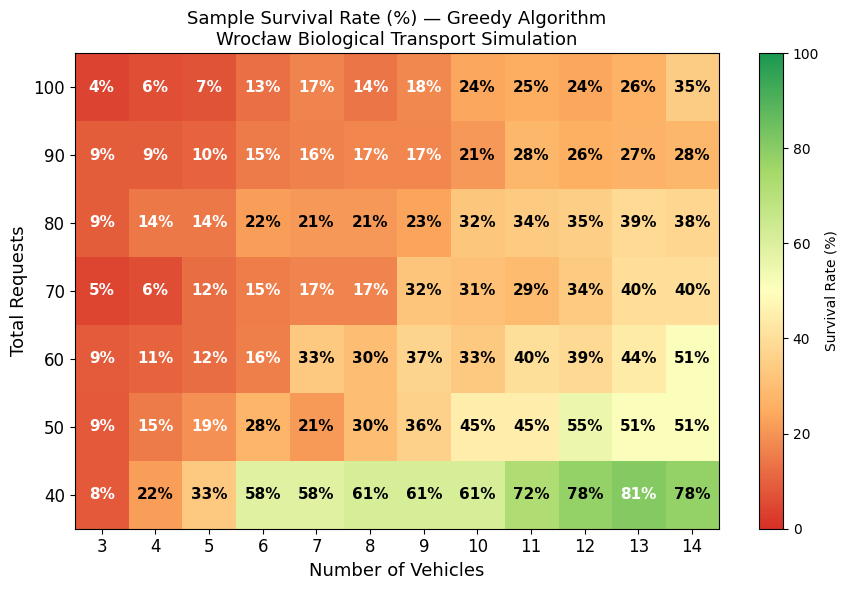

In [13]:
# %%
# ═══════════════════════════════════════════════════════════════════════════════
# GRID SEARCH: Survival Rate vs N_Vehicles × Total Requests
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functools

# ── 1. FAST SIMULATION (no snapshots, no deepcopy, parametric) ────────────────

def run_simulation_fast(requests_df, time_matrix, n_vehicles, algorithm_function,
                        shift_end, capacity=VEHICLE_CAPACITY):
    """
    Stripped-down simulation loop: no history_log, no deepcopy snapshots.
    Returns only the final path_history routes needed for evaluate().
    shift_end is passed in so we can scale the shift per experiment.
    """
    fleet = FleetState(n_vehicles, capacity)

    base_events = [float(x) for x in range(0, shift_end + 1, 15)]
    dynamic_events = requests_df[requests_df["is_dynamic"] == True]["appearance_time"].unique().tolist()
    events = sorted(set(base_events + dynamic_events))

    completed_requests = []

    for epoch_time in events:
        just_completed = fleet.advance_time(epoch_time, time_matrix, requests_df, completed_requests)
        completed_requests.extend(just_completed)

        visible_reqs = requests_df[requests_df["appearance_time"] <= epoch_time]
        active_pool  = visible_reqs[~visible_reqs["request_id"].isin(completed_requests)]

        dead_reqs = active_pool[active_pool["due_time"] < epoch_time]["request_id"].tolist()
        if dead_reqs:
            completed_requests.extend(dead_reqs)
            active_pool = active_pool[~active_pool["request_id"].isin(dead_reqs)]

        if active_pool.empty:
            continue

        new_routes = algorithm_function(active_pool, time_matrix, fleet.vehicles, capacity)
        for v, route in new_routes.items():
            fleet.vehicles[v]["assigned_route"] = route

    fleet.advance_time(shift_end + 500, time_matrix, requests_df, completed_requests)
    return {v: state["path_history"] for v, state in fleet.vehicles.items()}


# ── 2. REQUEST GENERATORS scaled to a target total count ─────────────────────

def generate_requests_for_grid(nodes_df, target_total, seed=SEED):
    """
    Generates static + dynamic requests so that the expected total ≈ target_total.
    We split 50/50: half static (one per lab up to target/2), half dynamic.
    Timings are scaled down proportionally to the shorter shift (120 min).
    """
    GRID_SHIFT = 120          # shorter shift for speed
    GRID_LAST_CALL = 30       # buffer before shift end

    rng_s = np.random.default_rng(seed)
    rng_d = np.random.default_rng(seed + 99)

    labs = nodes_df[nodes_df["type"] == "lab"].reset_index(drop=True)
    n_labs = len(labs)

    n_static  = min(target_total // 2, n_labs)   # can't exceed number of labs
    n_dynamic = target_total - n_static

    # Static requests — pick n_static labs at random
    chosen_labs = labs.sample(n=n_static, random_state=int(seed)).reset_index(drop=True)
    static_rows = []
    for i, (_, row) in enumerate(chosen_labs.iterrows()):
        ready = int(np.clip(rng_s.normal(0, 5), 0, 20))
        static_rows.append({
            "request_id":       i + 1,
            "lab_node_id":      int(row["node_id"]),
            "demand":           max(1, int(rng_s.normal(10, 5))),
            "appearance_time":  0.0,
            "ready_time":       ready,
            "due_time":         ready + int(np.clip(rng_s.normal(60, 10), 40, 90)),
            "service_time":     max(1, int(rng_s.normal(4, 1))),
            "max_transport_time": max(20, int(rng_s.normal(45, 10))),
            "is_dynamic":       False,
        })
    df_static = pd.DataFrame(static_rows)

    # Dynamic requests — Poisson arrivals across the short shift
    cutoff = GRID_SHIFT - GRID_LAST_CALL
    if n_dynamic > 0:
        avg_gap = cutoff / n_dynamic
        inter   = rng_d.exponential(scale=avg_gap, size=n_dynamic * 3)
        times   = np.cumsum(inter)
        times   = times[times < cutoff][:n_dynamic]
    else:
        times = np.array([])

    dynamic_rows = []
    for req_id, t in enumerate(times, start=9000):
        lab = labs.sample(1, random_state=int(rng_d.integers(0, 10000))).iloc[0]
        dynamic_rows.append({
            "request_id":       req_id,
            "lab_node_id":      int(lab["node_id"]),
            "demand":           max(1, int(rng_d.normal(10, 5))),
            "appearance_time":  round(t, 1),
            "ready_time":       round(t, 1),
            "due_time":         round(t + 50, 1),
            "service_time":     4.0,
            "max_transport_time": 30.0,
            "is_dynamic":       True,
        })
    df_dynamic = pd.DataFrame(dynamic_rows)

    return pd.concat([df_static, df_dynamic], ignore_index=True)


# ── 3. GRID RUNNER ────────────────────────────────────────────────────────────

def run_survival_grid(nodes_df, time_matrix, dist_matrix):
    GRID_SHIFT    = 120
    GRID_CAPACITY = VEHICLE_CAPACITY

    vehicle_counts = list(range(3, 15))          # 3–8 inclusive
    request_totals = list(range(40, 110, 10))    # 30,40,50,60,70,80

    # We use greedy only — it's 10-50× faster than OR-Tools and good enough for comparison
    algorithm = dynamic_greedy_routing

    n_rows = len(request_totals)
    n_cols = len(vehicle_counts)
    grid   = np.full((n_rows, n_cols), np.nan)

    total_sims = n_rows * n_cols
    done = 0

    for r_idx, n_req in enumerate(request_totals):
        requests_df = generate_requests_for_grid(nodes_df, target_total=n_req)

        for v_idx, n_veh in enumerate(vehicle_counts):
            print(f"  [{done+1}/{total_sims}] vehicles={n_veh}, requests≈{n_req}", end=" ... ")

            routes = run_simulation_fast(
                requests_df, time_matrix, n_veh, algorithm,
                shift_end=GRID_SHIFT, capacity=GRID_CAPACITY
            )

            # Prepend depot if missing (matches what main_dynamic does before evaluate)
            for v in routes:
                if not routes[v] or routes[v][0] != 0:
                    routes[v] = [0] + routes[v]

            metrics = evaluate(routes, requests_df, time_matrix, dist_matrix,
                               scenario_name=f"v={n_veh} r={n_req}", vehicle_caps=None)

            grid[r_idx, v_idx] = metrics["service_level_%"]
            done += 1
            print(f"survival={grid[r_idx, v_idx]:.1f}%")

    return grid, vehicle_counts, request_totals


# ── 4. HEATMAP PLOT ───────────────────────────────────────────────────────────

def plot_survival_grid(grid, vehicle_counts, request_totals, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 6))

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "survival", ["#d73027", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"]
    )
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto", origin="lower")

    ax.set_xticks(range(len(vehicle_counts)))
    ax.set_xticklabels(vehicle_counts, fontsize=12)
    ax.set_yticks(range(len(request_totals)))
    ax.set_yticklabels(request_totals, fontsize=12)
    ax.set_xlabel("Number of Vehicles", fontsize=13)
    ax.set_ylabel("Total Requests", fontsize=13)
    ax.set_title("Sample Survival Rate (%) — Greedy Algorithm\nWrocław Biological Transport Simulation", fontsize=13)

    for r in range(len(request_totals)):
        for c in range(len(vehicle_counts)):
            val = grid[r, c]
            text_color = "black" if 20 < val < 80 else "white"
            ax.text(c, r, f"{val:.0f}%", ha="center", va="center",
                    fontsize=11, color=text_color, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Survival Rate (%)")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {out_path}")
    plt.show()


# ── 5. ENTRY POINT ────────────────────────────────────────────────────────────
# Assumes nodes_df, time_matrix, dist_matrix are already built from main_dynamic()
# or from the cells above. Run this after those are available:

grid, vehicle_counts, request_totals = run_survival_grid(nodes_df, time_matrix, dist_matrix)
plot_survival_grid(grid, vehicle_counts, request_totals, out_path="output_dynamic/survival_grid.png")